# Does post-earnings drift wait for the stock to clear its earnings-day high?

In [1]:

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
ROOT = Path.cwd() if (Path.cwd() / "outputs").exists() else Path.cwd().parent
T, F = ROOT / "outputs" / "tables", ROOT / "outputs" / "figures"
def load(name, **kw): return pd.read_csv(T / name, **kw)
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 60)
print("tables:", T)


tables: /Users/woodylei/traders@ust/outputs/tables


**Author:** Lei Kam Fai (Woody). **Submission for:** Quant Team Recruitment, Round 1. **Date:** 13 September 2026.
**Data:** Massive REST API (US stock prices and reference data) and SEC EDGAR (filing timestamps). **Code:** this repository.

## Summary in plain words

Many traders are taught: after a great earnings report, do not buy straight away; wait until the stock closes above the high of the earnings day, then buy the "breakout". I tested whether the extra return after good earnings really arrives *after* that breakout.

I looked at 14,770 cases from 2005 to 2026 where a US stock had a top-10% price reaction on its earnings day. I compared two simple rules on exactly the same cases and the same 40-day window:

* **Rule A** buys at the open of the next day and sells 40 trading days after the earnings day.
* **Rule B** waits, buys at the open after the first close above the earnings-day high, and sells on the same day as Rule A. If the stock never breaks out, Rule B does nothing.

**Result: the idea does not hold.** After a breakout, the stock drifts no more than it does on average; if anything, slightly less (about 0.9 basis points per day less, and the confidence interval excludes zero). Rule B earned *less* than Rule A, especially in 2005 to 2014 (about 0.9% less per case, and the gap is statistically clear), and about the same in 2015 to 2026. The reason is partly mechanical: on every case that does break out, Rule B skips the run-up that Rule A collected, and Rule B can only win if the cases that never break out fall a lot. "Wait for a higher close" rules that use other price levels behave exactly like Rule B, and so does a placebo test on days with no news. Buying right after the report earned a modest +1.4% over 40 days before 2015 and nothing after, and even the early drift disappears once realistic trading costs are charged.

So the honest conclusion is: **the hypothesis is rejected**, the original way of testing it was flawed, and the small drift that exists is old and not tradable.

## 1. The research question

After a strong earnings reaction, does the stock's extra return (relative to the market) arrive steadily from the next day, or does most of it arrive only after the stock first closes above the high of the earnings day? This is a question about *when* returns arrive, not about how large they are.

## 2. The hypothesis, and what would count as evidence

**Hypothesis (H1).** For stocks with a top-decile earnings-day reaction, the average abnormal return *per day* after the first close above the earnings-day high is higher than the average abnormal return per day that these stocks earn anyway over the same days.

**The null (H0).** Returns per day after the breakout are no different from the normal path.

**Secondary version (the proposal's original wording).** Rule B earns a higher 40-day return than Rule A.

**What was fixed in advance, and what was not.** Before any result, `docs/PLAN.md` (02:05) fixed the rules, the controls, the filters, the default parameters and this test: the per-day abnormal return *after* the breakout must beat both the per-day return *before* it and the per-day return of events that never break out. After the first run I realised that the first half of that test is meaningless, because the days before a breakout are, by definition, days on which the stock went up (see the toy example in section 7). I therefore replaced it, *before* running the parameter grid or any robustness check, with the comparison against the normal path over the same days, defined in section 8. This change is logged (`logs/decision_log.csv`, 02:13) and the discarded version is kept in the tables as a descriptive row so that nothing is hidden. The second half of the original test (post-breakout beats non-breakout events) is numerically satisfied, but for the same reason it is not evidence about timing: events that never break out are defined by having gone down.

Support for H1 would have required: a positive primary statistic with a 95% confidence interval excluding zero in *both* the 2005 to 2014 period and the 2015 to 2026 period; the control rules (section 7) *not* showing the same pattern; and a flat placebo.

## 3. Why we thought the effect might exist

* **Post-earnings drift is a classic finding.** Ball and Brown (1968) and Bernard and Thomas (1989, 1990) showed that after earnings news, prices keep moving in the same direction for weeks. But Martineau (2022) argues this drift has disappeared for large US stocks since about 2006. So I expected the drift itself to be small.
* **Two behavioural stories predict a late move.** First, holders sitting on gains sell into good news (the "disposition effect", Frazzini 2006; Grinblatt and Han 2005); their selling can hold the price down until it is absorbed. Second, a price level such as a recent high can act as an anchor; once it is cleared, buying may accelerate (George and Hwang 2004; Huddart, Lang and Yetman 2009 study this for the 52-week high).
* **Attention.** If the late move is a delayed reaction, it should be bigger when fewer people are paying attention, for example for Friday announcements (DellaVigna and Pollet 2009; Hirshleifer, Lim and Teoh 2009).
* **A caution.** My "strong report" is defined by the price reaction, not by the earnings surprise. Foster, Olsen and Shevlin (1984) found little short-term drift when sorting on the reaction, and Chan, Jegadeesh and Lakonishok (1996) found it mostly at 6 to 12 months. So a small Rule A return was the expected baseline.

## 4. What changed from the proposal, and why

The proposal was written before I had API access. Once I could read the documentation in detail and run probe calls, several things had to change. Each change is a dated row in `logs/decision_log.csv`.

| # | What the proposal said | What I found | What had been tested at that point | What I did instead, and why it is better | What I learned |
|---|---|---|---|---|---|
| 1 | Classify reports as before-open or after-close from the timestamp on the Massive 8-K endpoint | That endpoint has a filing *date* but no time. Its earnings tags also start only in 2020 and missed most earnings releases on a test day | Nothing modelled yet, only probes | Used the SEC EDGAR "submissions" feed, which gives the exact time the SEC accepted each 8-K and whether it contains Item 2.02 (results of operations). Better because the acceptance time is the moment the filing became public, so day 0 is point-in-time by construction | Check the field list, not just the endpoint name |
| 2 | Rank events into the top 10% *within each quarter* | You do not know the quarter's ranking when the first events of the quarter happen: that is look-ahead | Nothing run | Threshold = 90th percentile of reactions over the *previous* four quarters, known on the day. Better because a trader could have applied it in real time | Every selection rule must be computable on the trade date |
| 3 | Rule B "buys once the stock closes above the high" | You cannot buy at a closing price you have not seen yet | Nothing run | All rules buy at the *next open* after the signal; a "buy at the close" version is reported as a robustness check. Better because every fill uses a price that existed after the decision | Define the fill price before the hypothesis |
| 4 | Rule B beating Rule A would show that drift is concentrated after the breakout | On every case that breaks out, Rule A's return contains Rule B's return *plus* the run-up. So A beats B automatically on those cases; B can only win overall if non-breakout cases fall a lot | Nothing had been run when B-versus-A was demoted at the design review (02:05). The first replacement (post-breakout minus pre-breakout per day) was run once on the default cell (E00, 02:13) and then itself replaced by the matched-path statistic before the grid or any robustness run | Made the primary test a comparison of the per-day return after the breakout with the normal per-day return over the same days; kept B versus A as a secondary result with control rules. Better because it isolates the only part of the return a breakout trader actually receives and compares like with like | Write down the algebra of a comparison before coding it |
| 5 | Use "Ticker Events" for delistings | That endpoint only lists symbol changes | Probe | Built the list of dead stocks from the ticker master (active = false) and matched events by company ID (CIK). Better because 21.7% of the final sample is in stocks that no longer trade, which a ticker-based match would have lost | Survivorship protection has to be built, not assumed |
| 6 | Estimate spreads from tick-level quotes | Far too much data for the machine, and not needed | Probe | Corwin-Schultz (2012) spread estimate from daily highs and lows. Better because it is computable for every event from data already in hand and is a published, validated estimator | Use what is already downloaded |
| 7 | Use Benzinga earnings data or income statements as a second "surprise" measure | Benzinga returned "not entitled" (HTTP 403) | Probe | Surprise measured by the price reaction only, with two alternative cut-offs as robustness. Better than a non-point-in-time income-statement value, and it is the variable the breakout rule is actually about | Probe entitlements before designing around a dataset |
| 8 | Splits *and dividends* for price adjustment | The Dividends endpoint works, but over 40-session windows dividends move returns by a few basis points, and the primary statistic compares the same stocks over the same days, so dividends cancel | Nothing run | Split-adjusted price returns only; dividends stated as a limitation. Better because it adjusts for what matters at this horizon and avoids a second adjustment path to validate | Adjust for what matters at the horizon studied |

**Row 4 in plain words.** Of the 14,769 cases with a tradable day-1 open, 8,974 closed above the day-0 high within 10 days and 5,795 never did. On the 8,974, Rule A was already holding the stock while it rose to the breakout (+3.79% on average) and then held the same position as Rule B (+0.34%); so A beat B on almost every one of them. On the 5,795, Rule B earned nothing and Rule A lost 5.10%. Whether "B beats A" therefore depends only on how badly the non-breakout cases do, which says nothing about whether returns arrive late. Section 9.2 shows these numbers by period.

## 5. Data

### 5.1 Massive (the central dataset)

* **Daily prices for the whole US market**, one API call per weekday from January 2004 to 11 September 2026 (5,988 calls). I asked for *unadjusted* prices and adjusted for stock splits myself using the Splits table, so that price filters use the real historical price level. My adjustment factors match the vendor's own factors, and my adjusted closes match the vendor's adjusted series on split days (`tests/test_api_crosscheck.py`).
* **Ticker master**: 36,588 US tickers including 6,609 delisted common stocks, with the company ID (CIK) needed to link filings to prices.
* **Splits**: 27,541 events.
* The SPY ETF, taken from the same daily file, is the market benchmark.

### 5.2 External data: SEC EDGAR

The SEC's submissions feed (`data.sec.gov/submissions/`) lists every filing a company ever made, with the exact time the SEC accepted it and the item numbers it contains. I downloaded it for 9,679 companies (9,672 found) and kept 8-K filings with Item 2.02, which is the item companies use to furnish their earnings press release: 321,077 filings. The data is free, public and point-in-time by construction, because the acceptance time is the moment the filing became public. I followed the SEC's rules (descriptive User-Agent, under 10 requests per second).

### 5.3 Cleaning

Duplicate rows removed; the trading calendar is the set of days on which SPY traded; returns across missing days are treated as missing; only common stocks (type "CS") on NYSE, Nasdaq and NYSE American are kept. Raw and per-stock data are *not* in the repository because they are licensed; only aggregate tables and figures are committed.

### 5.4 Timestamps and "what was known when"

Every event is dated to **day 0 = the first trading session that could react**:

* accepted before 09:30 New York time: day 0 is that day;
* accepted at or after 16:00: day 0 is the next trading day;
* accepted between 09:30 and 16:00: ambiguous ("intraday"); excluded from the main sample, included in a robustness run.

I checked this dating against the prices: for after-close and before-open filings, the biggest move (in absolute terms) falls on the assigned day 0 in about 64% of cases and on the day after in about 20%. The rest is mostly noise or 8-Ks filed some hours after the press release. This misdating adds noise but affects Rule A and Rule B in the same way. All filters use data from day -1 or earlier, the selection threshold uses only earlier quarters, and every trade happens at the open *after* the signal.

In [2]:
funnel = load("sample_funnel.csv"); tv = load("timing_validation.csv", index_col=0)
print("How the sample was built (number of events remaining after each step):"); display(funnel)
print("Share of events whose largest daily move falls on day -1, day 0 or day +1:"); display(tv.round(3))

How the sample was built (number of events remaining after each step):


,step,n_events
0,edgar_item202_rows,321077
1,8k_not_amended,318081
2,unique_cik_day0,316021
3,with_candidate_ticker,311923
4,matched_to_prices,288469
5,after_dedupe_20d,271534
6,exchange_filter,271460
7,plus_price_filter,226721
8,plus_liquidity_filter,184493
9,plus_history_filter,181927


Share of events whose largest daily move falls on day -1, day 0 or day +1:


,peak_on_d0,peak_on_dm1,peak_on_d1,n
timing,,,,
amc,0.648,0.155,0.196,72264.0
bmo,0.635,0.134,0.231,73545.0
intraday,0.336,0.183,0.481,36118.0
all,0.581,0.152,0.267,181927.0


## 6. Which events we study

Of 316,021 unique company-day-0 filings, 288,469 could be matched to a common-stock price series and 271,534 remain after removing follow-up filings within 20 sessions; 142,358 of those pass the filters (price at least $5 on day -1, median daily dollar volume over the previous 60 days at least $1 million, at least 120 days of history, not intraday, inside 2005 to mid-2026). Of these, **14,770 are "strong reports"**: their day-0 abnormal return is at or above the 90th percentile of the previous four quarters (the median cut-off is +8.1%). One of them has no tradable open on day 1 because its price series ends, so every return table is computed on 14,769 (the same rule removes one and two events from the +5% and two-standard-deviation alternative selections). They cover 3,116 different stocks and 86 quarters, and 21.7% of them are stocks that have since been delisted, so the sample is not biased toward survivors.

Two features matter for everything that follows. First, these are big moves: the median day-0 abnormal return is +12.4% and the median overnight gap is +6.6%. Second, almost half of them close in the top fifth of their day-0 range, so for those the "earnings-day high" is barely above the close and is cleared on day 1 by any small gain.

,value
statistic,
n_selected_events,14769.000
n_tickers,3116.000
n_quarters,86.000
share_amc,0.548
share_friday_day0,0.218
median_ar0,0.124
mean_ar0,0.145
median_threshold,0.081
median_overnight_gap,0.066


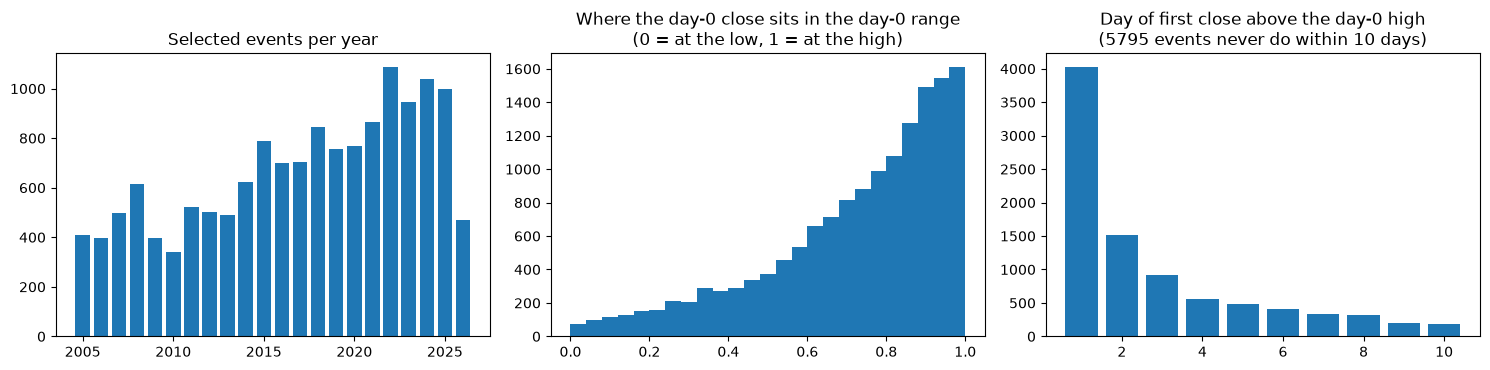

In [3]:
desc = load("event_descriptives.csv", index_col=0); display(desc.round(3))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
y = load("events_per_year.csv"); axes[0].bar(y.year, y.n_selected_events); axes[0].set_title("Selected events per year")
h = load("range_pos_hist.csv"); axes[1].bar(h.bin_left, h.n_events, width=0.04, align="edge"); axes[1].set_title("Where the day-0 close sits in the day-0 range\n(0 = at the low, 1 = at the high)")
k = load("breakout_day_hist_W10_H40.csv"); kk = k[k.k_B != "none"]; axes[2].bar(kk.k_B.astype(int), kk.n_events); axes[2].set_title(f"Day of first close above the day-0 high\n({int(k[k.k_B=='none'].n_events.iloc[0])} events never do within 10 days)")
plt.tight_layout(); plt.show()

## 7. The two rules and the controls, with a toy example

All days are trading days counted from day 0. **H** is the holding length (40 in the main run) and **W** is the maximum number of days we are willing to wait for a breakout (10 in the main run).

* **Rule A:** buy at the open of day 1, sell at the close of day H.
* **Rule B:** find the first day k (1 to W) whose close is above the day-0 high. Buy at the open of day k+1, sell at the close of day H. If there is no such day, do nothing (return 0).
* **Rule C (fixed delay):** the median breakout day in 2005 to 2014 is day 2, so C buys unconditionally at the open of day 3, exactly when Rule B would buy after a day-2 signal, and sells at the close of day H. C waits as long as B typically waits but never looks at prices. If B beats C, the *breakout* matters; if not, only the *waiting* mattered.
* **Rules D1, D2, D3 (other levels):** like B, but the trigger is a close above the day-0 close (D1), above 1.03 times the day-0 high (D2), or above the day-1 high (D3). If these behave like B, the earnings-day high is not a special level.

All returns are **abnormal returns**: the stock's return minus SPY's return over the same span. Stocks that stop trading inside the window (17 cases) are sold at their last price.

**Toy example.** A stock closes day 0 at $100 with a day-0 high of $104. Rule A buys at $100 at the day-1 open. Suppose the stock closes at $105 on day 3, its first close above $104. Rule B buys at the day-4 open at $105. Both sell at $110 on day 40. Rule A made +10%. Rule B made +4.8%. Rule A's +10% is the run-up (+5%) *combined with* Rule B's +4.8%. In general, on every breakout case Rule A = (1 + run-up from the day-1 open to the entry open) x (1 + Rule B) - 1. The run-up is positive whenever the entry open is above the day-1 open, which is nearly always the case after a close above the day-0 high (it averages +3.79%), so **on breakout cases Rule A almost always earns more than Rule B.** Rule B can only come out ahead on average if the stocks that *never* break out lose a lot, because on those Rule B earns 0 while Rule A takes the loss. That is why "B beats A" cannot, on its own, tell us anything about timing.

In [4]:
# The identity in numbers: A = (1 + run-up) * (1 + B) - 1 on every breakout case.
p0_close, p0_high, p1_open, p3_close, p4_open, p40_close = 100, 104, 100, 105, 105, 110
ret_A = p40_close / p1_open - 1
ret_B = p40_close / p4_open - 1
run_up = p4_open / p1_open - 1
print(f"Rule A: {ret_A:+.2%}   Rule B: {ret_B:+.2%}   run-up A collected but B skipped: {run_up:+.2%}")
print(f"Check: (1 + run-up) * (1 + B) - 1 = {(1 + run_up) * (1 + ret_B) - 1:+.2%}  (equals Rule A)")
print("If the stock never closes above $104: Rule B = 0, Rule A = whatever happened (e.g. $92 -> -8%).")

Rule A: +10.00%   Rule B: +4.76%   run-up A collected but B skipped: +5.00%
Check: (1 + run-up) * (1 + B) - 1 = +10.00%  (equals Rule A)
If the stock never closes above $104: Rule B = 0, Rule A = whatever happened (e.g. $92 -> -8%).


## 8. How we measure and test

**Primary statistic (the timing test).** For each case that breaks out on day k, take its abnormal return per day from the entry (day k+1) to day H. Compare it with the abnormal return per day that *all* strong-report cases in the same quarter earned over those *same* days. The difference is the primary statistic. If drift really concentrates after breakouts, it is positive. Comparing with the same days and the same quarter removes the effect of "returns are higher early in the window" and of "that quarter was a good quarter". It also avoids the trap in the toy example: we never compare the post-breakout leg with the run-up that was conditioned on the breakout.

**Confidence intervals.** Earnings cluster in four seasons a year, so the 14,770 cases are far from independent. I treat each calendar quarter as one block (86 blocks) and resample blocks with replacement 5,000 times ("season-block bootstrap"). Every headline number comes with the resulting 95% interval, plus the share of quarters in which the number was positive.

**Calendar-time check.** I also form daily portfolios: on each trading day, average the abnormal return of every open Rule A position (and separately every Rule B position). This turns overlapping events into one daily series per rule; the difference series is tested with Newey-West standard errors, which correct for the fact that consecutive days are correlated.

**Parameters.** There are two tunable parameters: W (5, 10, 15, 20) and H (20, 40, 60). The default (10, 40) was fixed in advance. The 2005 to 2014 half chooses the best cell (largest lower confidence bound of the primary statistic); the 2015 to 2026 half is then reported for that cell. The whole grid is shown in section 10. All other choices were set once, by convention, before any result, and were not tuned; their sensitivity was checked afterwards (section 11). Optimising beyond this would only risk fitting noise.

| Choice | Value | Why it exists | Values considered | How chosen | Data used | Sensitivity |
|---|---|---|---|---|---|---|
| Max wait W | 10 | how long a breakout may take | 5, 10, 15, 20 | default fixed in advance; 2005-2014 picks 15 | selection half only | none: same conclusion in all 12 cells |
| Holding H | 40 | horizon over which drift is measured | 20, 40, 60 | as above | selection half only | none |
| "Strong report" cut | trailing-4-quarter 90th percentile of AR0 | defines the event | 85th, 95th; fixed +5%; z-score >= 2 | convention (top decile) | none (a priori) | B minus A between -0.07% and -0.54%; primary within 1 bp/day of base |
| Minimum price | $5 (day -1, unadjusted) | avoid penny-stock noise | $10 | convention | none | none |
| Minimum liquidity | median 60-day dollar volume >= $1M | tradability | $5M | convention | none | none |
| History | >= 120 bars | volatility estimate, no fresh IPOs | not varied | convention | none | not varied |
| Benchmark | SPY excess | simplicity | not varied | transparency | none | the primary statistic and placebo are benchmark-free |
| Breakout level | day-0 high | the hypothesis | day-0 close; 1.03 x high; day-1 high (controls) | hypothesis | none | all levels behave alike |
| Fill | next open after the signal close | attainability | signal close (robustness) | conservatism | none | -0.41% vs -0.34% |
| Costs | Corwin-Schultz half-spread + 5 bp per side | tradability verdict | not varied | literature | none | reported by liquidity third |

**A note on one table label.** `main_summary_W10_H40.csv` and `stratified_W10_H40.csv` still contain the discarded first statistic, labelled "post minus pre per-day AR (... descriptive only)". It is about -2.3% per day because the pre-breakout days are, by construction, up days. It is kept for transparency and is not the primary test.

## 9. Main results (default cell W = 10, H = 40)

### 9.1 Rule A: what happens after a strong report?

The average 40-day abnormal return of buying at the next open is **+0.55%** (95% CI -0.50% to +1.59%) over 2005 to 2026. It was **+1.43%** (+0.57% to +2.35%) in 2005 to 2014 and **+0.12%** (-1.29% to +1.55%) in 2015 to 2026. The daily calendar-time portfolio earns 2.9 basis points per day (Newey-West t = 2.5) overall, 5.2 (t = 3.8) before 2015 and 0.8 (t = 0.5) after. Drift after extreme positive reactions existed early in the sample and has faded, consistent with Martineau (2022).

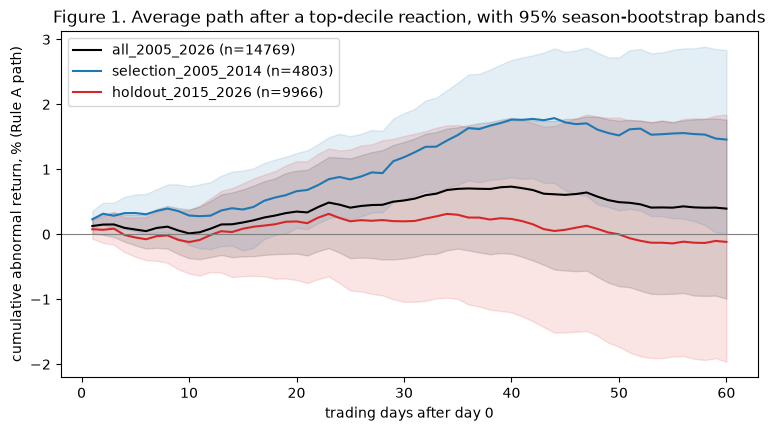

In [5]:
cp = load("car_path_means.csv")
fig, ax = plt.subplots(figsize=(9, 4.5))
for per, c in (("all_2005_2026", "k"), ("selection_2005_2014", "tab:blue"), ("holdout_2015_2026", "tab:red")):
    d = cp[cp.period == per]; ax.plot(d.day, d.mean_car_pct, color=c, label=f"{per} (n={int(d.n_events.iloc[0])})"); ax.fill_between(d.day, d.ci_lo_pct, d.ci_hi_pct, color=c, alpha=0.12)
ax.axhline(0, color="gray", lw=0.8); ax.set_xlabel("trading days after day 0"); ax.set_ylabel("cumulative abnormal return, % (Rule A path)"); ax.legend(); ax.set_title("Figure 1. Average path after a top-decile reaction, with 95% season-bootstrap bands"); plt.show()

### 9.2 Splitting the cases: breakout or not

60.8% of cases close above the day-0 high within 10 days, and 44.9% of those do it on day 1. The table below shows why the A-versus-B comparison is mechanical. Cases that break out earned +4.19% under Rule A but only +0.34% under Rule B, because the run-up before the entry was +3.79%. Cases that never break out lost 5.10% under Rule A, and Rule B sat them out.

In [6]:
dec = load("decomposition_W10_H40.csv")
cols = ["period", "group", "n", "share", "CAR_A", "CAR_B", "run_up_open1_to_entry", "post_entry_leg", "perday_A", "perday_post_entry"]
display(dec[cols].style.format({"share": "{:.1%}", "CAR_A": "{:+.2%}", "CAR_B": "{:+.2%}", "run_up_open1_to_entry": "{:+.2%}", "post_entry_leg": "{:+.2%}", "perday_A": "{:+.3%}", "perday_post_entry": "{:+.3%}"}, na_rep=""))

,period,group,n,share,CAR_A,CAR_B,run_up_open1_to_entry,post_entry_leg,perday_A,perday_post_entry
0,all_2005_2026,all events,14769,100.0%,+0.55%,+0.21%,+3.79%,+0.34%,+0.014%,+0.009%
1,all_2005_2026,breakout within W,8974,60.8%,+4.19%,+0.34%,+3.79%,+0.34%,+0.105%,+0.009%
2,all_2005_2026,no breakout within W,5795,39.2%,-5.10%,+0.00%,,,-0.128%,
3,selection_2005_2014,all events,4803,100.0%,+1.43%,+0.51%,+3.27%,+0.85%,+0.036%,+0.022%
4,selection_2005_2014,breakout within W,2898,60.3%,+4.16%,+0.85%,+3.27%,+0.85%,+0.104%,+0.022%
5,selection_2005_2014,no breakout within W,1905,39.7%,-2.73%,+0.00%,,,-0.068%,
6,holdout_2015_2026,all events,9966,100.0%,+0.12%,+0.06%,+4.04%,+0.10%,+0.003%,+0.003%
7,holdout_2015_2026,breakout within W,6076,61.0%,+4.21%,+0.10%,+4.04%,+0.10%,+0.105%,+0.003%
8,holdout_2015_2026,no breakout within W,3890,39.0%,-6.26%,+0.00%,,,-0.157%,


### 9.3 The primary test: is there extra drift after the breakout?

**No.** After the entry, breakout cases earned 0.9 basis points per day above the market; all strong-report cases earned 1.8 basis points per day over the same days. Breakout cases did slightly *worse*, not better. Concretely, breakout cases earned 0.9 basis points per day after the entry, and all strong-report cases earned 1.8 basis points per day over those same days. The primary statistic (the difference) is **-0.9 basis points per day (95% CI -1.5 to -0.2)** for 2005 to 2026, -1.5 (-2.4 to -0.6) in 2005 to 2014 and -0.6 (-1.4 to +0.3) in 2015 to 2026. The primary statistic lives in `outputs/tables/robustness_W10_H40.csv` (rows "base ... | all / selection / holdout", columns PRIMARY_post_minus_matched, PRIMARY_lo, PRIMARY_hi, matched_control_perday) and in `outputs/tables/grid_results.csv`; it is not in `main_summary_W10_H40.csv`. For scale, one basis point per day over the roughly 38 days after a median day-2 breakout is about 0.4% over the whole window. A small negative value is what the short-term reversal literature would predict after a large up day (Jegadeesh 1990; Lehmann 1990). Figure 2 shows the daily abnormal returns lined up on the breakout day: a big spike on the breakout day itself (which is what *defines* a breakout), and from the entry open onwards a path that sits on or just below the normal one.

**How to read Figure 2.** Day 0 on the x-axis is the breakout day k, not the earnings day. The red dot at 0 is huge because a breakout day is by definition a day the stock rose. Everything to the right of the green line is what a Rule B trader actually receives. It sits on or just below the grey squares, which show what all strong-report stocks earned on those same days in that same quarter. (Both series in the figure are close-to-close daily returns; the primary statistic in the text uses open-to-close spans for both sides, so the overnight gap into the entry day is excluded from both.)

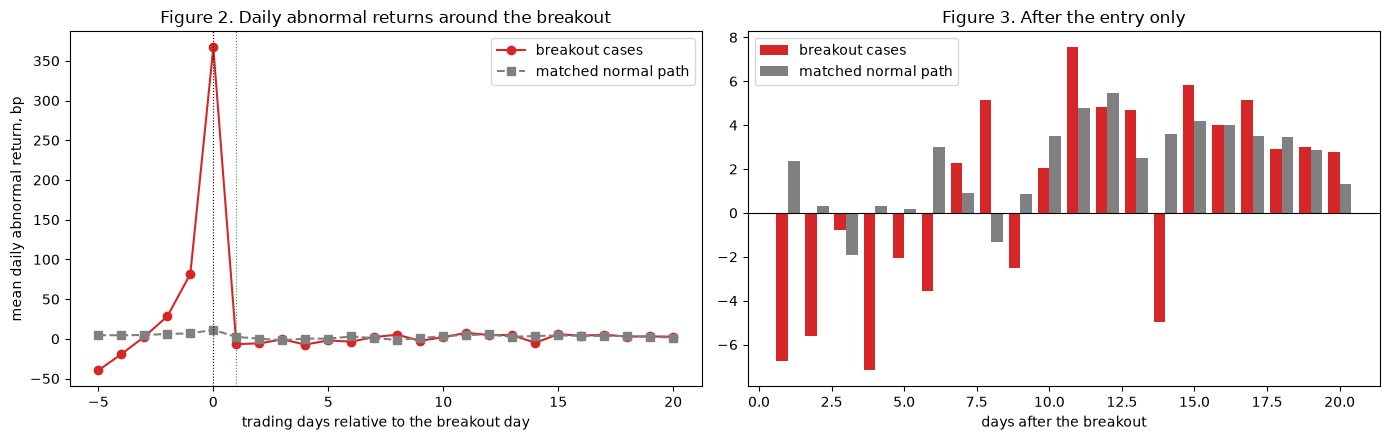

,period,statistic,mean,ci_lo,ci_hi,n_events
11,all_2005_2026,per-day AR pre-breakout leg (breakout events),+2.2800%,+2.1482%,+2.4073%,8974
12,all_2005_2026,per-day AR post-breakout leg (breakout events),+0.0090%,-0.0159%,+0.0348%,8974
13,all_2005_2026,per-day AR non-breakout events (1..H),-0.1275%,-0.1571%,-0.0982%,5795
14,all_2005_2026,per-day AR all events (Rule A),+0.0137%,-0.0125%,+0.0398%,14769
15,all_2005_2026,post minus pre per-day AR (breakout events; pre leg conditioned on the crossing; descriptive only),-2.2710%,-2.4057%,-2.1338%,8974
16,all_2005_2026,post-breakout per-day minus non-breakout per-day,+0.1366%,+0.1163%,+0.1558%,8974
28,selection_2005_2014,per-day AR pre-breakout leg (breakout events),+1.8804%,+1.6986%,+2.0788%,2898
29,selection_2005_2014,per-day AR post-breakout leg (breakout events),+0.0221%,-0.0005%,+0.0455%,2898
30,selection_2005_2014,per-day AR non-breakout events (1..H),-0.0682%,-0.0907%,-0.0420%,1905
31,selection_2005_2014,per-day AR all events (Rule A),+0.0356%,+0.0141%,+0.0587%,4803


In [7]:
ba = load("breakout_aligned_means.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(ba.tau, ba.breakout_events_mean_ar_bp, "o-", color="tab:red", label="breakout cases"); axes[0].plot(ba.tau, ba.matched_unconditional_mean_ar_bp, "s--", color="gray", label="matched normal path")
axes[0].axvline(0, color="k", ls=":", lw=0.8); axes[0].axvline(1, color="tab:green", ls=":", lw=0.8); axes[0].set_xlabel("trading days relative to the breakout day"); axes[0].set_ylabel("mean daily abnormal return, bp"); axes[0].legend(); axes[0].set_title("Figure 2. Daily abnormal returns around the breakout")
post = ba[ba.tau >= 1]; axes[1].bar(post.tau - 0.2, post.breakout_events_mean_ar_bp, 0.4, color="tab:red", label="breakout cases"); axes[1].bar(post.tau + 0.2, post.matched_unconditional_mean_ar_bp, 0.4, color="gray", label="matched normal path")
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_xlabel("days after the breakout"); axes[1].legend(); axes[1].set_title("Figure 3. After the entry only"); plt.tight_layout(); plt.show()
ms = load("main_summary_W10_H40.csv"); rows = ms[ms.statistic.str.contains("per-day|post-breakout")][["period", "statistic", "mean", "ci_lo", "ci_hi", "n_events"]]
display(rows.style.format({"mean": "{:+.4%}", "ci_lo": "{:+.4%}", "ci_hi": "{:+.4%}"}))

### 9.4 Rule B versus Rule A, and the control rules

Rule B earned **+0.21%** against Rule A's +0.55%: a difference of **-0.34% (95% CI -0.87% to +0.20%)**. In 2005 to 2014 the difference was **-0.92% (-1.41% to -0.46%)** and Rule B beat Rule A in only 28% of quarters; in 2015 to 2026 it was -0.06% (-0.77% to +0.67%). In calendar time, the B-minus-A daily series averages -1.8 basis points per day (Newey-West t = -2.9). Waiting for the breakout forgoes the run-up and collects nothing extra.

The controls confirm that nothing about the *earnings-day high* is special. The fixed-delay Rule C earned +0.45% (C minus A: -0.09%, CI -0.25% to +0.06%). The other-level rules D1, D2 and D3 earned +0.40%, +0.08% and +0.12%; in 2005 to 2014 their shortfalls against A (-0.46%, -1.13%, -1.06%) bracket Rule B's (-0.92%). Any "wait for a higher close" rule behaves like Rule B.

period,all_2005_2026,selection_2005_2014,holdout_2015_2026
statistic,,,
CAR_A (open1->closeH),+0.55%,+1.43%,+0.12%
"CAR_B (breakout entry, 0 if flat)",+0.21%,+0.51%,+0.06%
B minus A,-0.34%,-0.92%,-0.06%
CAR_C fixed delay m,+0.45%,+1.19%,+0.10%
C minus A,-0.09%,-0.24%,-0.02%
CAR_D1,+0.40%,+0.97%,+0.13%
D1 minus A,-0.15%,-0.46%,+0.00%
CAR_D2,+0.08%,+0.29%,-0.02%
D2 minus A,-0.46%,-1.13%,-0.14%


,period,series,mean_daily_bp,nw_se_bp,nw_t,n_days,ann_sharpe
0,all,rA,2.877,1.154,2.492,5409,0.537
1,all,rB,1.051,0.649,1.620,5409,0.334
2,all,d,-1.825,0.624,-2.923,5409,-0.665
3,selection,rA,5.204,1.377,3.781,2534,1.036
4,selection,rB,1.608,0.879,1.830,2534,0.529
5,selection,d,-3.596,0.724,-4.967,2534,-1.421
6,holdout,rA,0.825,1.764,0.468,2875,0.146
7,holdout,rB,0.561,0.939,0.597,2875,0.173
8,holdout,d,-0.264,0.948,-0.279,2875,-0.091


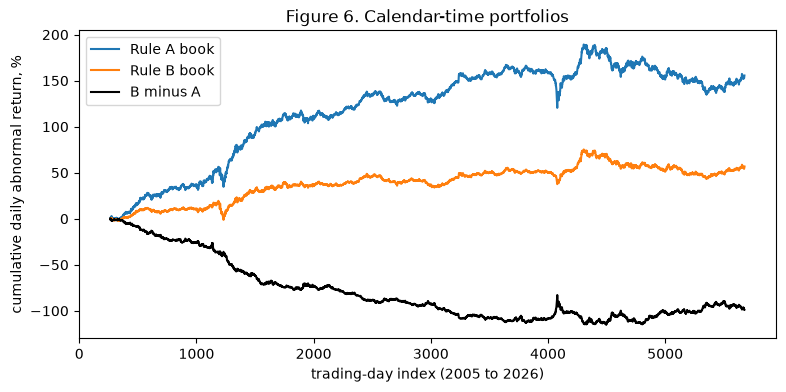

In [8]:
ms = load("main_summary_W10_H40.csv")
want = ["CAR_A (open1->closeH)", "CAR_B (breakout entry, 0 if flat)", "B minus A", "CAR_C fixed delay m", "C minus A", "CAR_D1", "D1 minus A", "CAR_D2", "D2 minus A", "CAR_D3", "D3 minus A"]
t = ms[ms.statistic.isin(want)].pivot(index="statistic", columns="period", values="mean").reindex(want)[["all_2005_2026", "selection_2005_2014", "holdout_2015_2026"]]
display(t.style.format("{:+.2%}"))
ct = load("calendar_time_W10_H40.csv"); display(ct.round(3))
s = load("calendar_time_series_W10_H40.csv", index_col=0)
fig, ax = plt.subplots(figsize=(9, 4)); ax.plot(s.index, s.rA.cumsum() * 100, label="Rule A book"); ax.plot(s.index, s.rB.cumsum() * 100, label="Rule B book"); ax.plot(s.index, s.d.cumsum() * 100, color="k", label="B minus A")
ax.set_xlabel("trading-day index (2005 to 2026)"); ax.set_ylabel("cumulative daily abnormal return, %"); ax.legend(); ax.set_title("Figure 6. Calendar-time portfolios"); plt.show()

## 10. Choosing the two parameters

The grid below covers every W and H combination for both halves of the sample. Rule B minus Rule A is negative in all 12 cells in 2005 to 2014 (the interval is entirely below zero in 11 of them) and its interval includes zero in all 12 cells in 2015 to 2026. The primary statistic lies between -1.8 and +0.3 basis points per day across all cells and periods, never significantly positive. The selection rule (largest lower confidence bound in 2005 to 2014) picked W = 20, H = 60 with a primary statistic of -0.9 bp/day (-1.5 to -0.4); in 2015 to 2026 that cell gives -0.1 bp/day (-0.7 to +0.5) and B minus A of +0.17% (-0.58% to +0.91%). **The conclusion does not depend on the parameters.**

selection_2005_2014 : Rule B minus Rule A (%)


H,20,40,60
W,,,
5,-0.45,-0.96,-0.70
10,-0.44,-0.92,-0.74
15,-0.42,-0.81,-0.69
20,-0.42,-0.78,-0.68


selection_2005_2014 : primary statistic (bp per day)


H,20,40,60
W,,,
5,-1.5,-1.2,-0.7
10,-1.7,-1.5,-1.0
15,-1.8,-1.3,-0.9
20,-1.8,-1.2,-0.9


holdout_2015_2026 : Rule B minus Rule A (%)


H,20,40,60
W,,,
5,-0.15,-0.04,0.19
10,-0.13,-0.06,0.10
15,-0.08,0.03,0.23
20,-0.10,-0.03,0.17


holdout_2015_2026 : primary statistic (bp per day)


H,20,40,60
W,,,
5,-1.5,-0.2,0.3
10,-1.7,-0.6,-0.2
15,-1.0,-0.3,0.1
20,-1.6,-0.7,-0.1


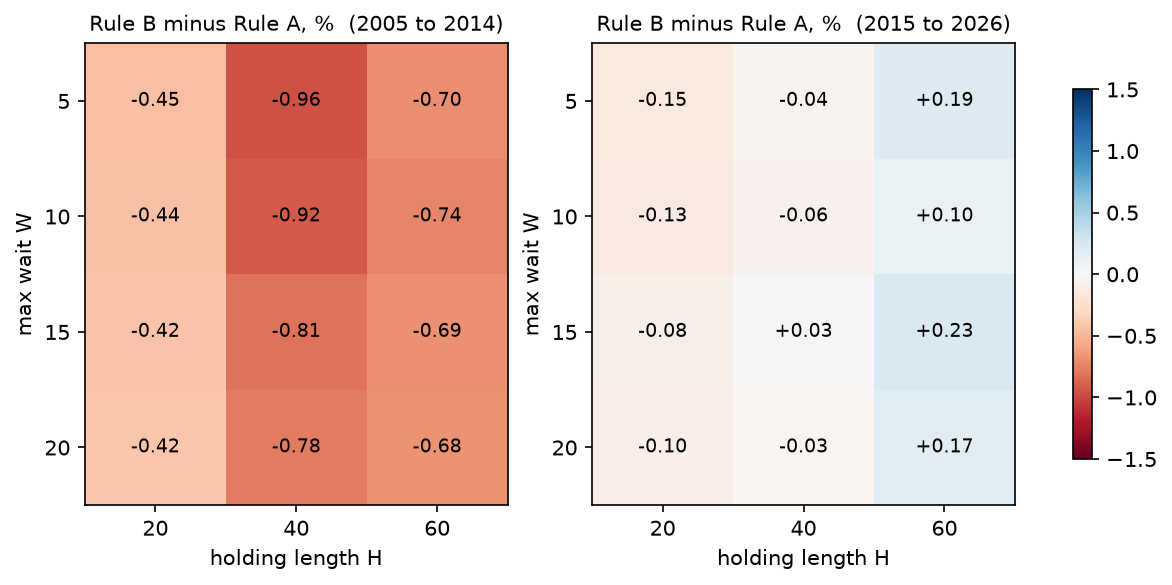

In [9]:
g = load("grid_results.csv")
for per in ("selection_2005_2014", "holdout_2015_2026"):
    print(per, ": Rule B minus Rule A (%)"); display((g[g.label == per].pivot(index="W", columns="H", values="B_minus_A") * 100).round(2))
    print(per, ": primary statistic (bp per day)"); display((g[g.label == per].pivot(index="W", columns="H", values="PRIMARY_post_minus_matched") * 1e4).round(1))
display(Image(filename=str(F / "fig5_grid_B_minus_A.png")))

## 11. Robustness checks and trading costs

Every variant below was run through the same engine and is logged in `logs/experiment_record.csv`, including the ones that made no difference.

* **Ignore day-1 breakouts** (trigger only from day 2): -0.37%; primary -0.9 bp/day (-1.6 to -0.2).
* **Buy at the signal close instead of the next open:** -0.41%; primary -1.2 bp/day (-1.8 to -0.5). Faster fills do not rescue Rule B.
* **Different "strong report" cut-offs:** a fixed +5% (26,610 cases) gives -0.18%; primary -0.7 bp/day (-1.2 to -0.2); a reaction of at least two standard deviations (35,515 cases) gives -0.07%; primary -0.5 bp/day (-0.8 to -0.1). Rule A's own return falls to +0.32% and +0.11% in these larger samples.
* **Looser or stricter definition** (trailing 85th or 95th percentile instead of the 90th): -0.24%; primary -0.8 bp/day (-1.3 to -0.3); and -0.54%; primary -1.2 bp/day (-2.1 to -0.4).
* **Stricter filters** (price at least $10; median dollar volume at least $5M): -0.22%; primary -0.7 bp/day (-1.3 to -0.1); and -0.21%; primary -0.8 bp/day (-1.5 to -0.1).
* **Include the ambiguous intraday filings:** -0.38%; primary -0.8 bp/day (-1.4 to -0.2).
* **Placebo with no news:** run the same rules on the same stocks 60 sessions *before* the earnings day. B trails A by about the same amount (-0.40%, CI -0.91% to +0.10%) even though "day 0" is an ordinary day with no announcement, and the primary statistic is -0.4 bp/day (-1.2 to +0.3). A gap that appears without news cannot be a news-timing effect.
* **Mirror image on the short side** (bottom-decile reactions, trigger = close below the day-0 low, returns and control both sign-flipped): -0.50%; primary -1.1 bp/day (-1.9 to -0.3). A symmetry check only; borrowing costs and short-sale rules are ignored.
* **Friday announcements** (21.8% of cases): the primary statistic is -2.8 bp/day (-4.7 to -0.8), the opposite sign to the attention story, against -0.3 bp/day (-1.1 to +0.4) for Monday to Thursday. This is one of many splits, so I report it as a curiosity, not a finding.
* **By liquidity** (low / mid / high thirds): B minus A -0.48% / -0.05% / -0.49%. No concentration in illiquid names.
* **By where the day-0 close sits in its range** (low / mid / high thirds): B minus A -0.70% / -0.31% / -0.01%. Rule B's shortfall is largest exactly where the anchor actually binds.

**Costs.** The Corwin-Schultz estimate of the bid-ask spread has a median of 0.82% and a mean of 0.96% (0.73% median for the most liquid third, 0.92% for the least liquid). Charging half the spread plus 5 basis points on each side removes about 1.06% per round trip and turns Rule A's +0.55% into **-0.52%** (CI -1.55% to +0.52%) and Rule B's +0.21% into -0.45% (-1.01% to +0.14%). By period (same table): in 2005 to 2014 Rule A nets +0.43% (-0.43% to +1.35%), indistinguishable from zero; in 2015 to 2026 it nets -0.97% (-2.37% to +0.45%).

In [10]:
rb = load("robustness_W10_H40.csv"); rb = rb[rb.period == "all"]
show = rb[["variant", "n_events", "share_entered_B", "CAR_A", "CAR_B", "B_minus_A", "B_minus_A_lo", "B_minus_A_hi", "PRIMARY_post_minus_matched", "PRIMARY_lo", "PRIMARY_hi"]].copy()
for c in ("PRIMARY_post_minus_matched", "PRIMARY_lo", "PRIMARY_hi"): show[c] = show[c] * 1e4
display(show.style.format({"share_entered_B": "{:.0%}", "CAR_A": "{:+.2%}", "CAR_B": "{:+.2%}", "B_minus_A": "{:+.2%}", "B_minus_A_lo": "{:+.2%}", "B_minus_A_hi": "{:+.2%}", "PRIMARY_post_minus_matched": "{:+.1f} bp", "PRIMARY_lo": "{:+.1f}", "PRIMARY_hi": "{:+.1f}"}))
costs = load("costs_W10_H40.csv"); display(costs[["group", "n", "median_spread", "gross_A", "net_A", "net_A_lo", "net_A_hi", "gross_B", "net_B", "net_B_lo", "net_B_hi"]].style.format({"median_spread": "{:.2%}", "gross_A": "{:+.2%}", "net_A": "{:+.2%}", "net_A_lo": "{:+.2%}", "net_A_hi": "{:+.2%}", "gross_B": "{:+.2%}", "net_B": "{:+.2%}", "net_B_lo": "{:+.2%}", "net_B_hi": "{:+.2%}"}))

,variant,n_events,share_entered_B,CAR_A,CAR_B,B_minus_A,B_minus_A_lo,B_minus_A_hi,PRIMARY_post_minus_matched,PRIMARY_lo,PRIMARY_hi
0,base top-decile trailing threshold,14769,61%,+0.55%,+0.21%,-0.34%,-0.87%,+0.20%,-0.9 bp,-1.5,-0.2
3,grid-selected cell W=20 H=60,14769,70%,+0.21%,+0.11%,-0.11%,-0.64%,+0.44%,-0.4 bp,-0.8,+0.1
6,trigger from day 2 (exclude day-1 breakouts),14769,58%,+0.55%,+0.18%,-0.37%,-0.94%,+0.21%,-0.9 bp,-1.6,-0.2
9,market-on-close entry for signal rules,14769,61%,+0.55%,+0.14%,-0.41%,-0.93%,+0.13%,-1.2 bp,-1.8,-0.5
12,selection: fixed AR0 >= 5%,26610,61%,+0.32%,+0.13%,-0.18%,-0.65%,+0.29%,-0.7 bp,-1.2,-0.2
15,selection: z0 >= 2,35515,61%,+0.11%,+0.04%,-0.07%,-0.44%,+0.34%,-0.5 bp,-0.8,-0.1
18,intraday filings included,16025,61%,+0.59%,+0.21%,-0.38%,-0.88%,+0.12%,-0.8 bp,-1.4,-0.2
21,placebo: pseudo day 0 = 60 sessions before the event,14744,67%,+1.24%,+0.84%,-0.40%,-0.91%,+0.10%,-0.4 bp,-1.2,+0.3
24,"short-side mirror (bottom decile, close < day-0 low), gross",14767,60%,+0.56%,+0.06%,-0.50%,-0.98%,+0.01%,-1.1 bp,-1.9,-0.3
27,selection: trailing 85th percentile,21978,61%,+0.40%,+0.16%,-0.24%,-0.72%,+0.26%,-0.8 bp,-1.3,-0.3


,group,n,median_spread,gross_A,net_A,net_A_lo,net_A_hi,gross_B,net_B,net_B_lo,net_B_hi
0,all,14769,0.82%,+0.55%,-0.52%,-1.55%,+0.52%,+0.21%,-0.45%,-1.01%,+0.14%
1,selection_2005_2014,4803,0.75%,+1.43%,+0.43%,-0.43%,+1.35%,+0.51%,-0.11%,-0.61%,+0.43%
2,holdout_2015_2026,9966,0.86%,+0.12%,-0.97%,-2.37%,+0.45%,+0.06%,-0.62%,-1.38%,+0.17%
3,liq high,4922,0.73%,+0.59%,-0.39%,-1.52%,+0.69%,+0.10%,-0.54%,-1.26%,+0.17%
4,liq low,4924,0.92%,+0.86%,-0.29%,-1.44%,+0.92%,+0.38%,-0.31%,-0.90%,+0.34%
5,liq mid,4923,0.81%,+0.19%,-0.86%,-2.02%,+0.34%,+0.14%,-0.49%,-1.15%,+0.18%


## 12. Assumptions and limitations

* **Event dating.** The 8-K acceptance time can be hours after the press release, so roughly one case in five is dated a session late. This adds noise to both rules equally; it does not create a bias in favour of either.
* **Exchange membership** is taken from today's ticker master rather than as of the event date. Symbol reuse is handled with validity windows, but rare mismatches are possible.
* **Abnormal return = stock minus SPY.** Dividends are ignored (short windows) and there is no beta or size adjustment. The matched-path primary statistic and the placebo do not depend on the benchmark, which is why they are the main evidence.
* **Costs are estimated**, not observed. The spread proxy is coarse for the least liquid names.
* **The placebo's Rule A level** (+1.24%) is not meaningful on its own: those stocks were chosen because of a strong reaction that came later. Only the B-versus-A comparison inside the placebo is used.
* **Effective sample size.** Earnings arrive in four seasons a year, so 86 quarter blocks, not 14,770 cases, determine the width of the confidence intervals.
* **Ten design choices** are listed in the parameter table in section 8. Only W and H were tuned, on 2005 to 2014, and reported on 2015 to 2026.
* **What the test could detect.** The primary statistic's 95% interval is about 1.3 basis points per day wide, so an extra post-breakout drift of about 0.7 basis points per day (roughly 0.3% over the window) would have been detected; smaller effects cannot be ruled out.

## 13. Conclusion

**The hypothesis is rejected, for four reasons.**

1. **No extra drift after the breakout.** After a stock closes above its earnings-day high, it earns 0.9 basis points per day above the market; all strongly reacting stocks earn 1.8 basis points per day over the same days. The difference is -0.9 bp per day with a 95% interval of -1.5 to -0.2, and it stays within a few basis points of zero in every period and parameter cell and in every pre-specified robustness variant. The one split with an interval away from zero (Friday announcements) has the wrong sign for the hypothesis and is one of many splits. With interval half-widths of about 0.7 basis points per day, the test would have detected an extra drift of roughly 0.3% over the 40-day window.
2. **Waiting costs money.** Rule B earned 0.34% less than Rule A over 2005 to 2026, 0.92% less in 2005 to 2014 (interval -1.41% to -0.46%, B ahead in only 28% of quarters), and about the same after 2015.
3. **The earnings-day high is not special.** Triggers at other price levels and a fixed two-day delay behave like Rule B, and B trails A by the same amount on ordinary days with no news. The proposal's test (B beats A) was biased against B by construction, so even a win for B would not have shown that returns arrive late.
4. **The drift itself is small, old and untradable.** Buying at the next open earned +1.43% over 40 days before 2015 and +0.12% after; estimated round-trip costs of about 1.1% leave +0.43% (CI -0.43% to +1.35%) before 2015 and -0.97% after: nothing distinguishable from zero.

In the language of the brief: for the *timing* claim, "the original result was caused by a methodological issue"; for the drift itself, "the result exists before costs but is not practically tradable", and only before 2015.

## 14. What I would investigate next

1. Date events by the press-release time (a newswire or earnings-calendar feed) and measure how much the 8-K lag matters.
2. Condition on a fundamental surprise (reported versus expected EPS and revenue) crossed with the price reaction; the strongest drift evidence in the literature is for surprise sorts.
3. Test the anchoring story where the literature places it: nearness to the 52-week high and the capital-gains position of holders measured *before* the announcement, with volume as the extra prediction.
4. Build a matched control from non-earnings days with equally large moves, to separate earnings-specific continuation from ordinary short-term momentum.

## Glossary

* **Abnormal return:** the stock's return minus SPY's return over the same span; what the stock did beyond the market.
* **Day 0:** the first trading session that could react to the earnings release.
* **CAR (cumulative abnormal return):** abnormal return added up over a window, here 40 trading days.
* **Breakout:** the first close above the high of day 0, within W days.
* **Basis point (bp):** one hundredth of one percent. 10 bp = 0.10%.
* **Look-ahead bias:** using information that was not available at the time a decision is made. Example: ranking a January event against the whole quarter's events.
* **Survivorship bias:** studying only companies that still exist today, which drops the failures.
* **Season-block bootstrap:** to get a confidence interval, resample whole quarters (with replacement) many times and recompute the statistic; this respects the fact that earnings cluster in quarters.
* **95% confidence interval (CI):** the range of values consistent with the data; if it includes zero, the effect is not distinguishable from zero.
* **Calendar-time portfolio:** on each day, the average return of all positions open that day; it turns overlapping events into one daily series.
* **Newey-West t-statistic:** a t-statistic whose standard error is corrected for correlation between consecutive days.
* **Corwin-Schultz spread:** an estimate of the bid-ask spread computed only from daily highs and lows.
* **Point-in-time:** using, for each date, only the information that existed on that date (for example, the price level before later stock splits, or a threshold built from earlier quarters).

## Questions an interviewer may ask, and short answers

1. **Why did Rule B lose to Rule A in 2005 to 2014?** Because on breakout cases A holds B's position plus a +3.3% run-up, and the non-breakout cases (40% of the sample) lost only 2.7% under A in that period; that is not enough for B's zeros to make up the difference. The table in section 9.2 shows both pieces.
2. **Is the result just because breakouts on day 1 are trivial?** No. Excluding day-1 breakouts gives -0.37% (versus -0.34%), and Rule B's shortfall is largest in the cases where the close was far below the high, where the anchor really binds.
3. **How do you know the primary statistic is not biased by the selection on breakouts?** The post-entry leg starts *after* the breakout day and is compared with what all strong-report stocks earned over the same days in the same quarter. The breakout-day spike itself (Figure 2, day 0) is excluded from both sides.
4. **What would have convinced you the hypothesis was true?** A primary statistic with a 95% interval above zero in both halves of the sample, plus Rules C and D failing to reproduce it, plus a flat placebo. None of the three happened: the statistic is -1.5 bp/day (-2.4 to -0.6) in 2005 to 2014 and -0.6 bp/day (-1.4 to +0.3) in 2015 to 2026.
5. **Where is the look-ahead in the original proposal?** The within-quarter decile ranking and the "buy at the signal close" rule. Both were replaced before any test was run, and both are logged.
6. **Could misdated events explain the null?** They add noise but no bias: misdating shifts the anchor and the entry for A and B alike, and the timing validation shows 64% correct dating with most of the rest one day late.
7. **Why SPY as benchmark and not a size-matched portfolio?** Simplicity and transparency. The primary statistic compares stocks with themselves over the same days, so the benchmark cancels out in the main test; the placebo provides a second benchmark-free check.
8. **Is anything here tradable?** No. Round-trip costs of about 1.1% exceed the +0.55% gross return of Rule A; before 2015 the drift nets +0.43% (CI -0.43% to +1.35%) after costs, indistinguishable from zero.

## References

Ball, R. and Brown, P. (1968). An empirical evaluation of accounting income numbers. *Journal of Accounting Research* 6, 159-178.
Bernard, V. and Thomas, J. (1989). Post-earnings-announcement drift: delayed price response or risk premium? *Journal of Accounting Research* 27 (Suppl.), 1-36.
Bernard, V. and Thomas, J. (1990). Evidence that stock prices do not fully reflect the implications of current earnings for future earnings. *Journal of Accounting and Economics* 13, 305-340.
Chan, L., Jegadeesh, N. and Lakonishok, J. (1996). Momentum strategies. *Journal of Finance* 51, 1681-1713.
Corwin, S. and Schultz, P. (2012). A simple way to estimate bid-ask spreads from daily high and low prices. *Journal of Finance* 67, 719-760.
DellaVigna, S. and Pollet, J. (2009). Investor inattention and Friday earnings announcements. *Journal of Finance* 64, 709-749.
Foster, G., Olsen, C. and Shevlin, T. (1984). Earnings releases, anomalies, and the behavior of security returns. *Accounting Review* 59, 574-603.
Frazzini, A. (2006). The disposition effect and underreaction to news. *Journal of Finance* 61, 2017-2046.
George, T. and Hwang, C.-Y. (2004). The 52-week high and momentum investing. *Journal of Finance* 59, 2145-2176.
Grinblatt, M. and Han, B. (2005). Prospect theory, mental accounting, and momentum. *Journal of Financial Economics* 78, 311-339.
Hirshleifer, D., Lim, S. and Teoh, S. H. (2009). Driven to distraction: extraneous events and underreaction to earnings news. *Journal of Finance* 64, 2289-2325.
Jegadeesh, N. (1990). Evidence of predictable behavior of security returns. *Journal of Finance* 45, 881-898.
Lehmann, B. (1990). Fads, martingales, and market efficiency. *Quarterly Journal of Economics* 105, 1-28.
Huddart, S., Lang, M. and Yetman, M. (2009). Volume and price patterns around a stock's 52-week highs and lows. *Management Science* 55, 16-31.
Martineau, C. (2022). Rest in peace post-earnings announcement drift. *Critical Finance Review* 11, 613-646.

## Appendix: reproducing this report

`scripts/run_all.py` runs every stage (downloads, panel, events, main run, grid, robustness, figures, aggregate export). `scripts/build_notebook.py` rebuilds this document, as `notebooks/report.ipynb` and `docs/report.md`, from the committed tables in `outputs/tables/` only; it needs no licensed data. Tests: `python -m pytest -q`.